# Objectif 

Suite du notebook usefull_portion_acouplane_1.ipynb. 

Ici on se concentre sur l'intersection d'interêt. 

Fichiers preprocessés :

* Données de positions : acouplane_pos.nc
* Données de pression : acouplane_raw_pressure.nc

Date de création : 06/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

In [2]:
if os.name == "nt":  # Windows
    ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
else:  # Linux
    ROOT_PROGRAM = "/home/program/ubf_tools"
sys.path.append(ROOT_PROGRAM)

from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *

# Cherche d'un portion d'intérêt par analyse des données de position

## Chargement des données 

In [3]:
ds_pos = xr.open_dataset(ACOUPLANE_POSITIONS_NC_FPATH)

In [4]:
selected_day = datetime(2026, 2, 25)
ds_pos_day = ds_pos.sel(
    atl_datetime=selected_day.strftime(format="%Y/%m/%d"),
    ais_datetime=selected_day.strftime(format="%Y/%m/%d"),
    src_datetime=selected_day.strftime(format="%Y/%m/%d")
    )

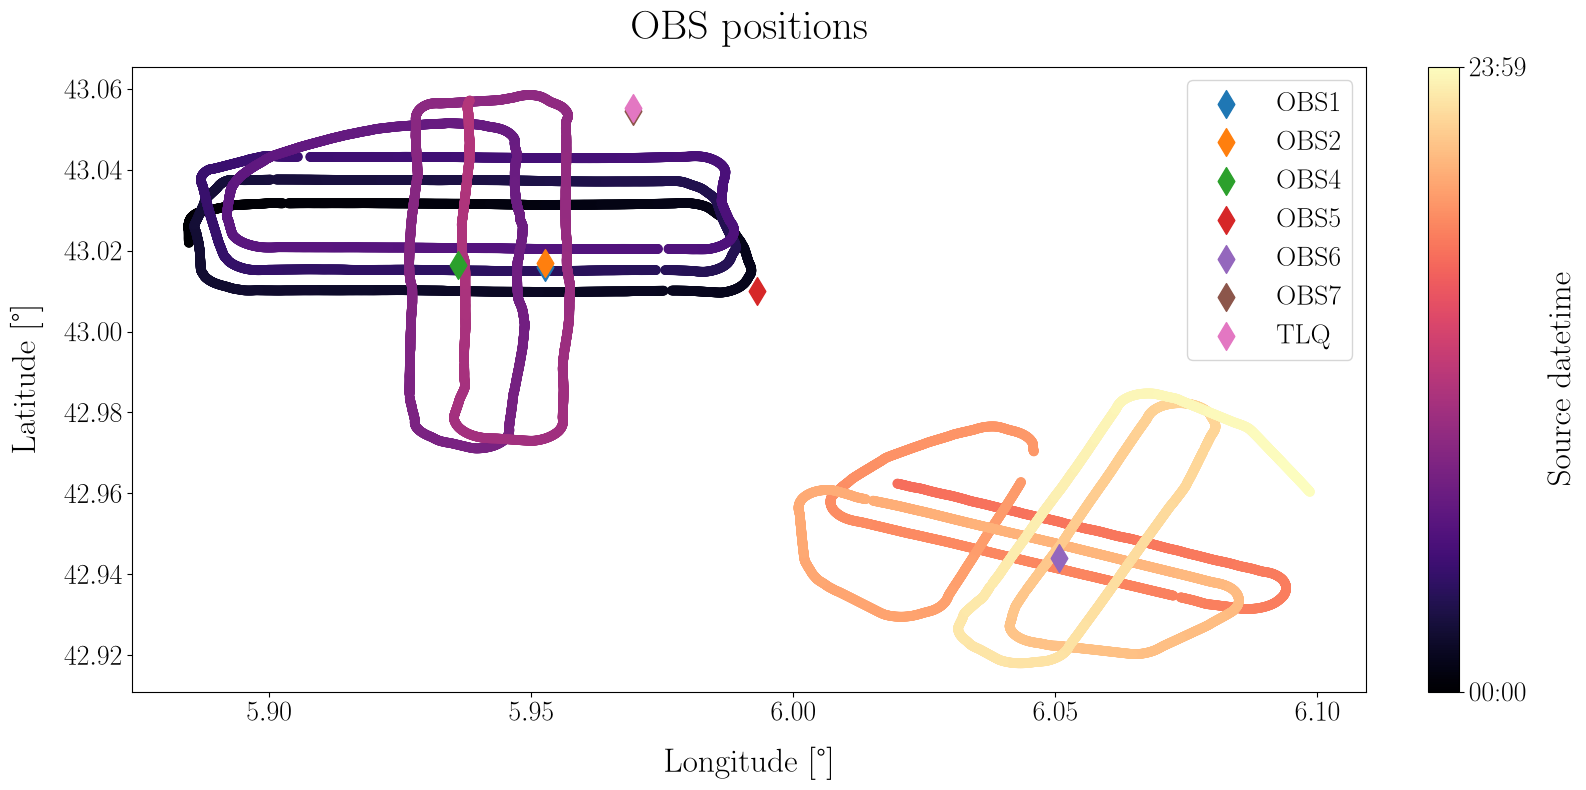

In [5]:
fig, ax = plt.subplots()

dates = ds_pos_day.src_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos_day.tir_src_lon,
    ds_pos_day.tir_src_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos_day, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Source datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

### Selection de chaque sections 

<Axes: title={'center': 'OBS positions'}, xlabel='Longitude [°]', ylabel='Latitude [°]'>

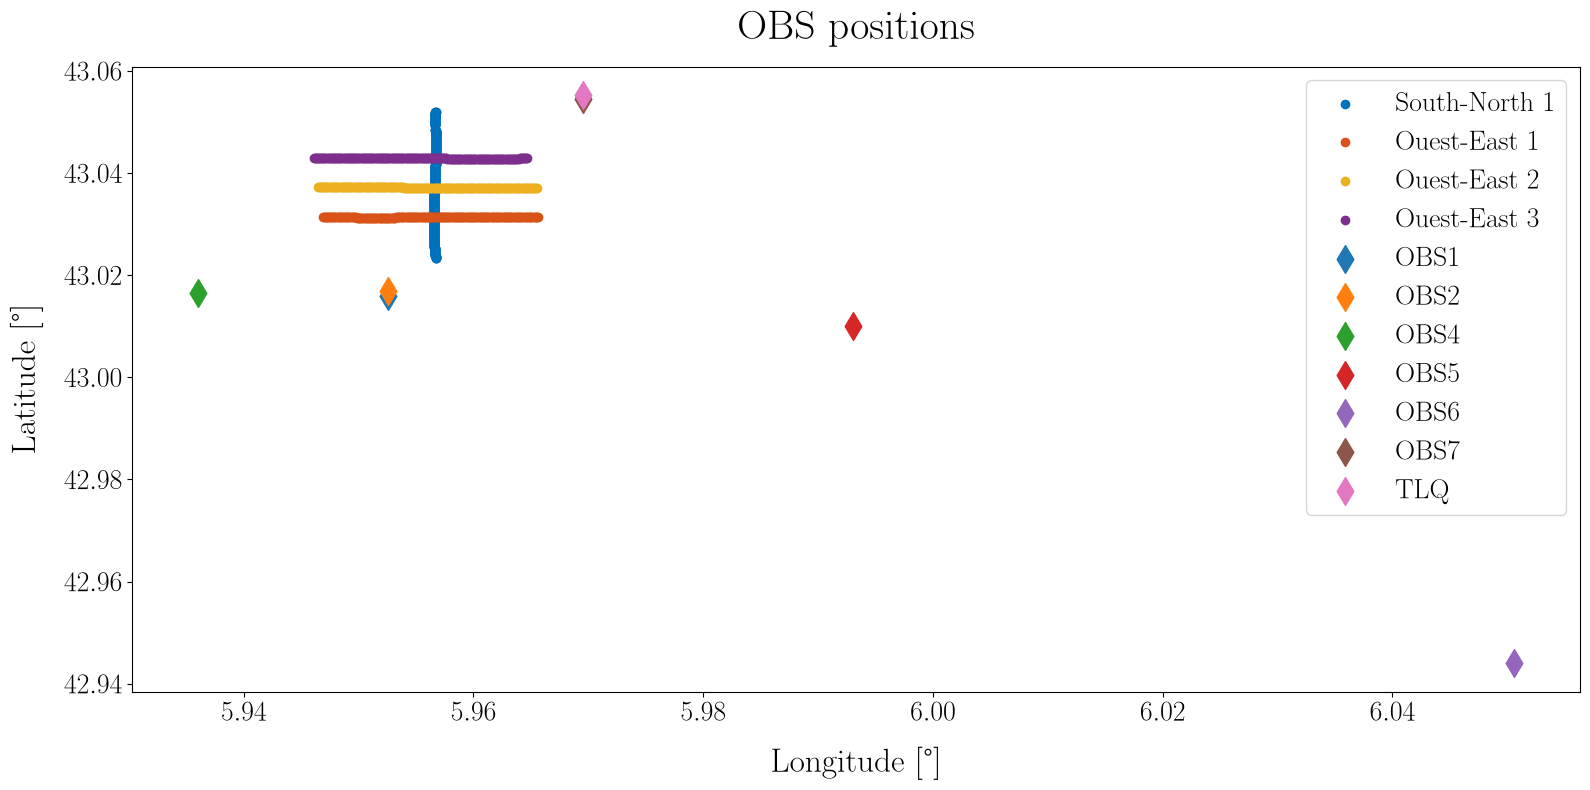

In [16]:
section_sn1_start = datetime(2026, 2, 25, 9, 50)
section_sn1_end = datetime(2026, 2, 25, 10, 10)
ds_pos_section_sn1 = select_pos_section(section_start=section_sn1_start, section_end=section_sn1_end, ds_pos=ds_pos)

section_oe1_start = datetime(2026, 2, 25, 0, 42)
section_oe1_end = datetime(2026, 2, 25, 0, 52)
ds_pos_section_oe1 = select_pos_section(section_start=section_oe1_start, section_end=section_oe1_end, ds_pos=ds_pos)

section_oe2_start = datetime(2026, 2, 25, 3, 2)
section_oe2_end = datetime(2026, 2, 25, 3, 12)
ds_pos_section_oe2 = select_pos_section(section_start=section_oe2_start, section_end=section_oe2_end, ds_pos=ds_pos)

section_oe3_start = datetime(2026, 2, 25, 5, 15)
section_oe3_end = datetime(2026, 2, 25, 5, 25)
ds_pos_section_oe3 = select_pos_section(section_start=section_oe3_start, section_end=section_oe3_end, ds_pos=ds_pos)

# Plot all
ds_pos_sections = [ds_pos_section_sn1, ds_pos_section_oe1, ds_pos_section_oe2, ds_pos_section_oe3]
pos_section_label = ["South-North 1", "Ouest-East 1", "Ouest-East 2", "Ouest-East 3"]

fig, ax = plt.subplots()

for i, ds_pos_section in enumerate(ds_pos_sections):
    sc = ax.scatter(
        ds_pos_section.tir_src_lon,
        ds_pos_section.tir_src_lat,
        color=color(i), 
        label=pos_section_label[i]
    )

plot_obs_pos(ds_pos_section, ax=ax)

# Données de pression

## Chargement des données 

In [17]:
ds_pressure = xr.open_dataset(ACOUPLANE_PRESSURE_NC_FPATH)

## Convertion des données et calcul vecteurs temps pour slicing 

Les données stockées sont les données raw, il faut donc les convertir et fabriquer le vecteur de temps.

In [18]:
# Build a vector of datetime for each OBS signal
obs_datetimes = build_obs_datetime_vector(ds_pressure=ds_pressure)

## Données des sections

In [19]:
ds_pressure

<xarray.Dataset> Size: 22GB
Dimensions:         (time_obs1: 995998000, time_obs2: 1000246000,
                     time_obs4: 993598000, time_obs5: 831598000,
                     time_obs6: 818998000, time_obs7: 850176000, obs_id: 6)
Coordinates:
  * obs_id          (obs_id) <U4 96B 'obs1' 'obs2' 'obs4' 'obs5' 'obs6' 'obs7'
Dimensions without coordinates: time_obs1, time_obs2, time_obs4, time_obs5,
                                time_obs6, time_obs7
Data variables:
    pressure_obs1   (time_obs1) int32 4GB ...
    pressure_obs2   (time_obs2) int32 4GB ...
    pressure_obs4   (time_obs4) int32 4GB ...
    pressure_obs5   (time_obs5) int32 3GB ...
    pressure_obs6   (time_obs6) int32 3GB ...
    pressure_obs7   (time_obs7) int32 3GB ...
    start_datetime  (obs_id) datetime64[ns] 48B ...
Attributes:
    description:  Données de pression (voie hydro 3)
    campagne:     ACOUPLANE
    fs:           2000
    fullscale:    4.52

### Section Sud Nord 1

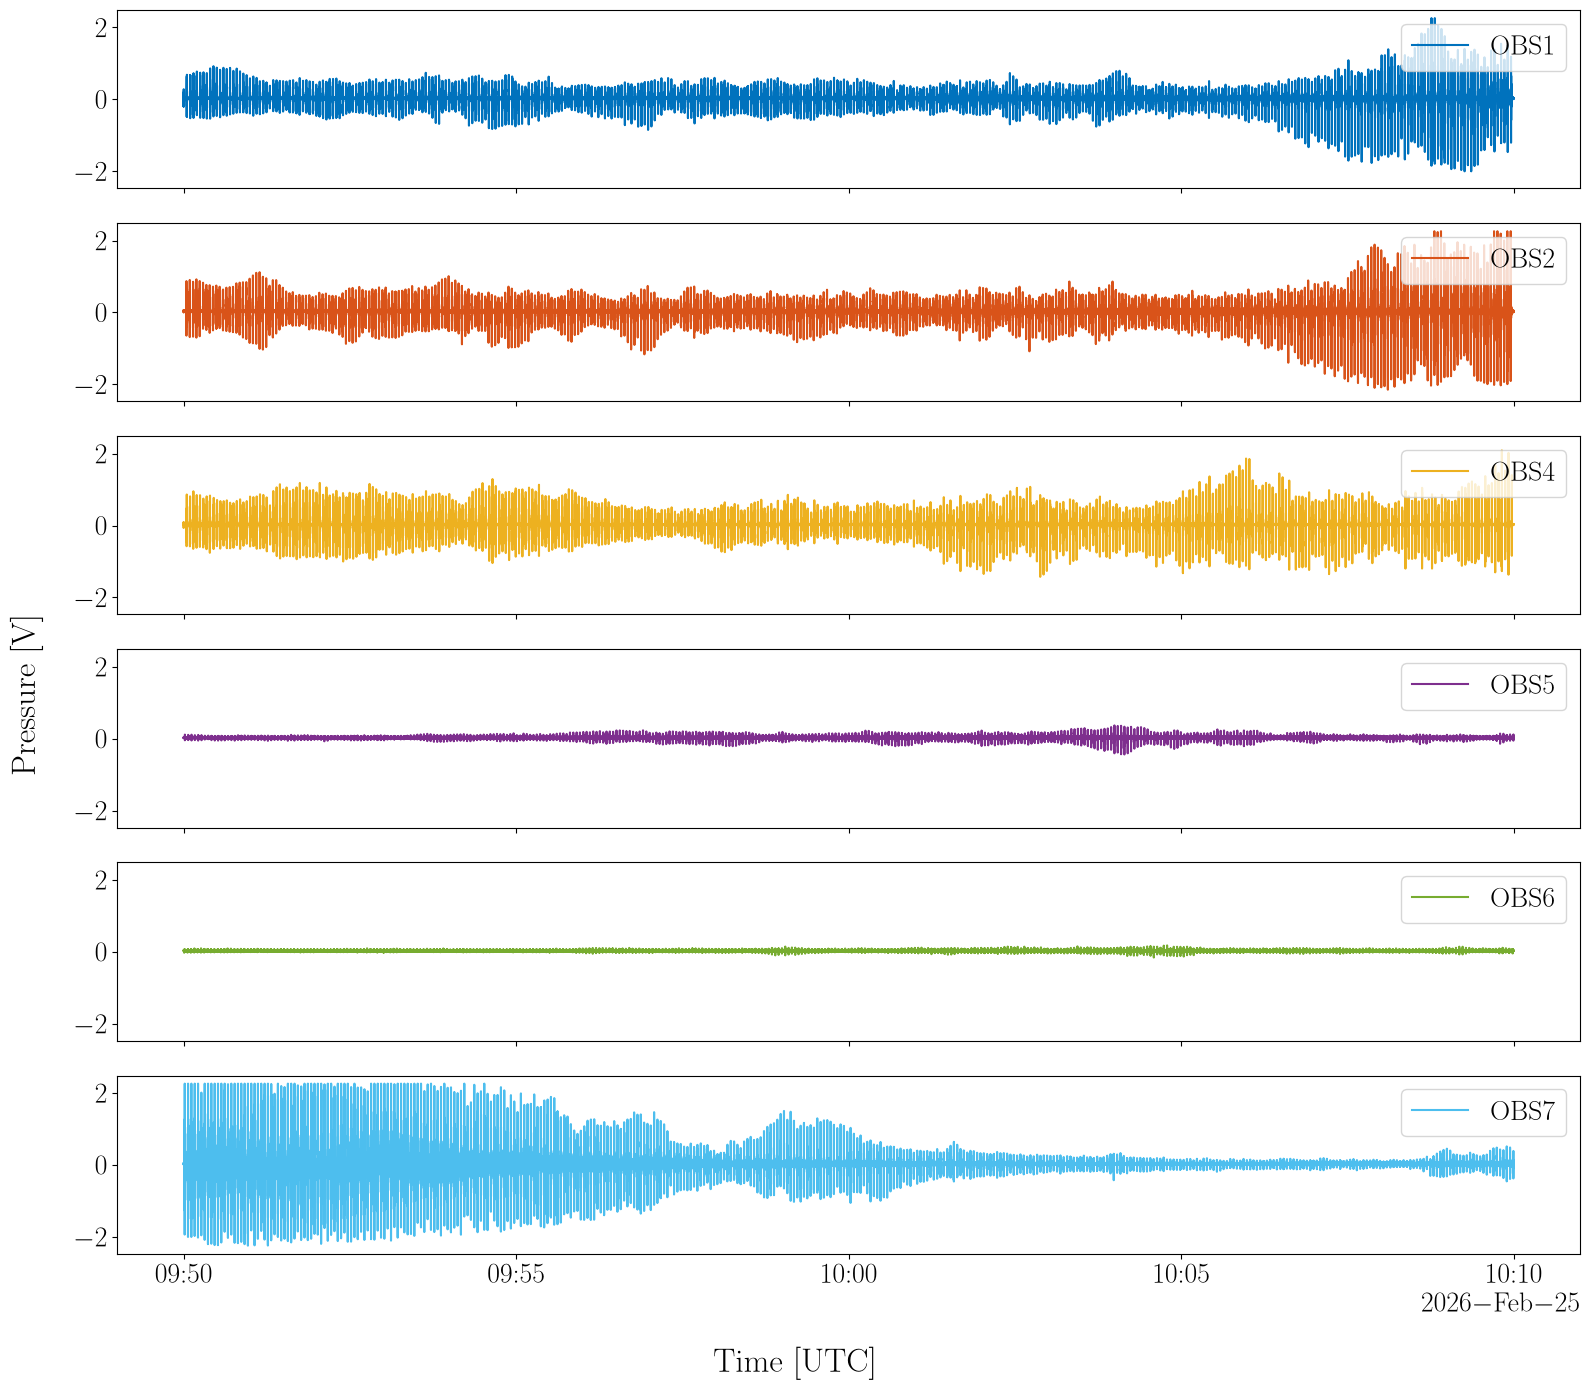

In [20]:
ds_pressure_section_sn1 = extract_and_plot_pressure_section(section_sn1_start, section_sn1_end, ds_pressure, obs_datetimes, single_fig=False)

### Section Ouest Est 1

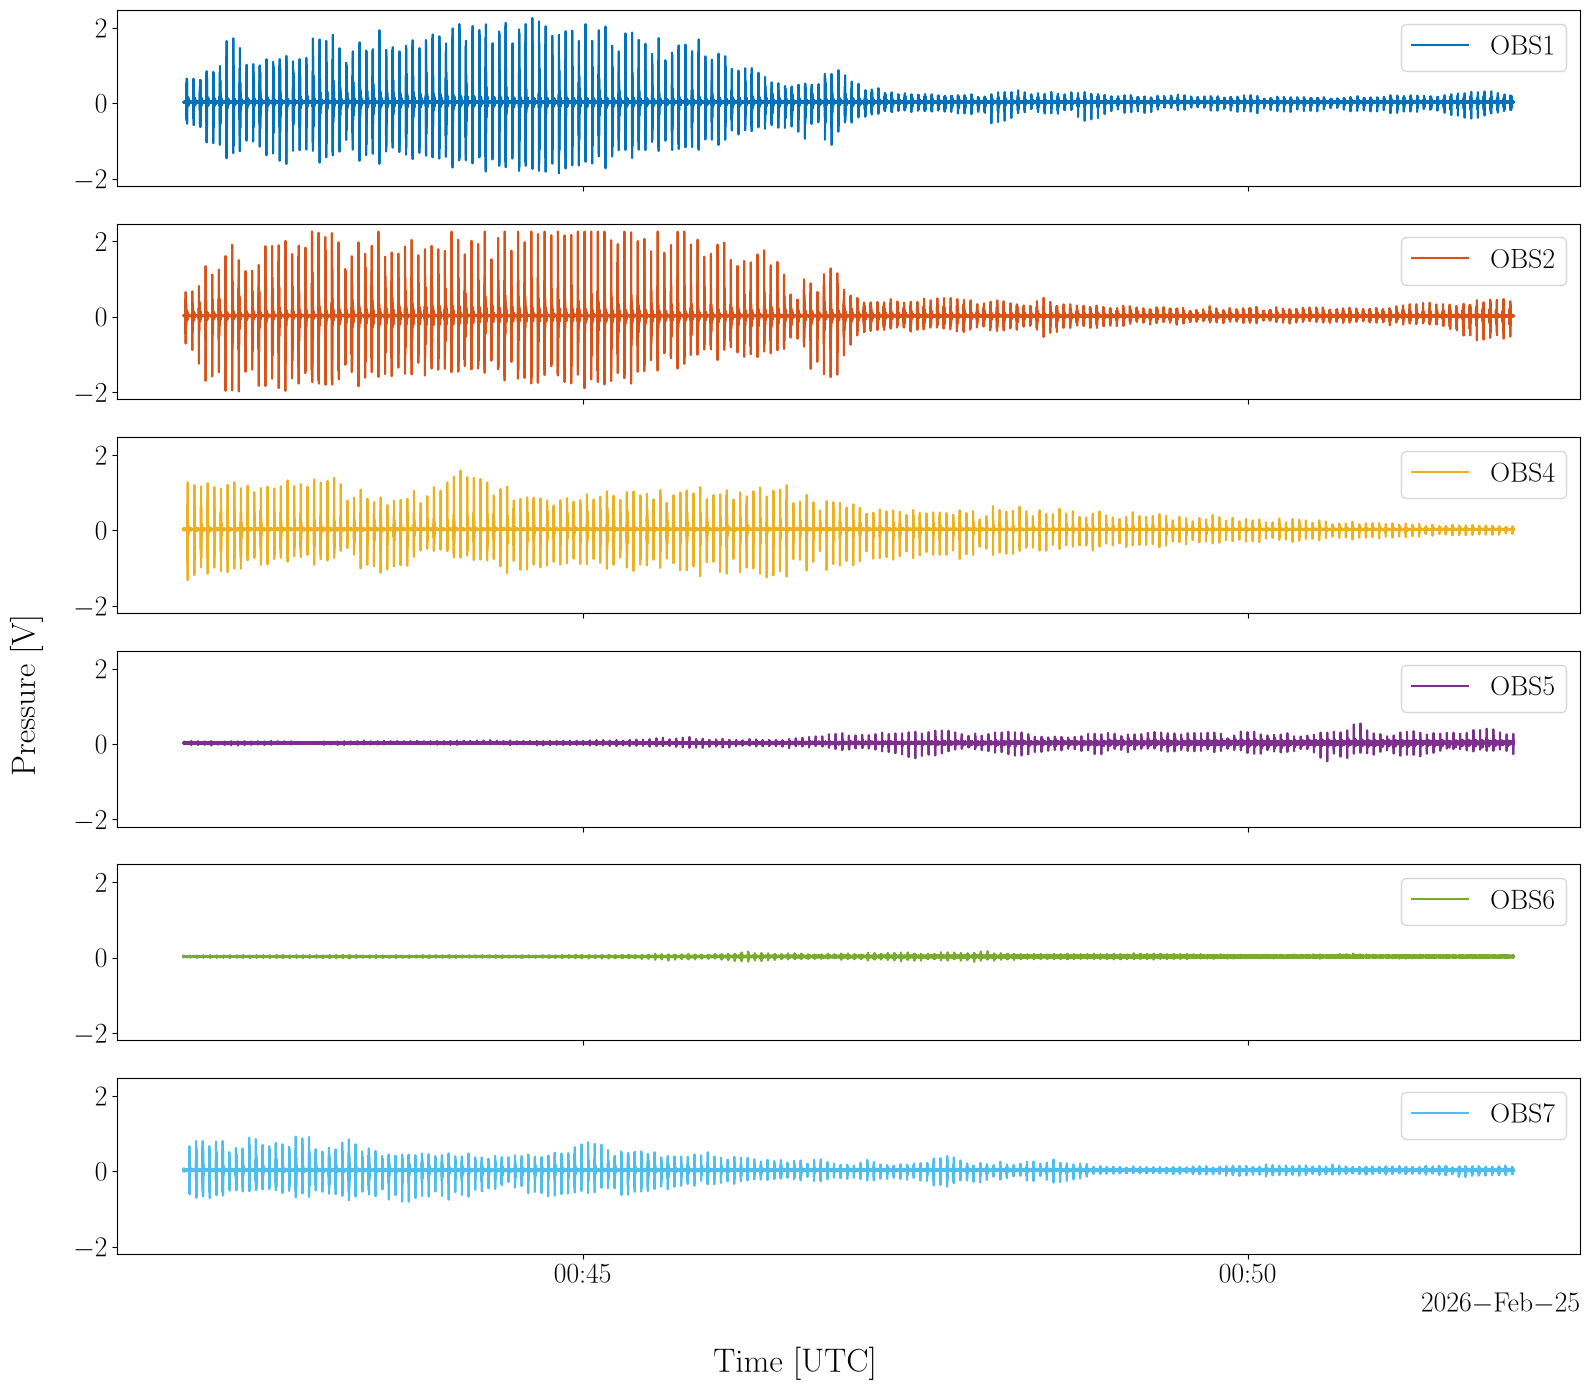

In [21]:
ds_pressure_section_oe1 = extract_and_plot_pressure_section(section_oe1_start, section_oe1_end, ds_pressure, obs_datetimes, single_fig=False)

### Section Ouest Est 2

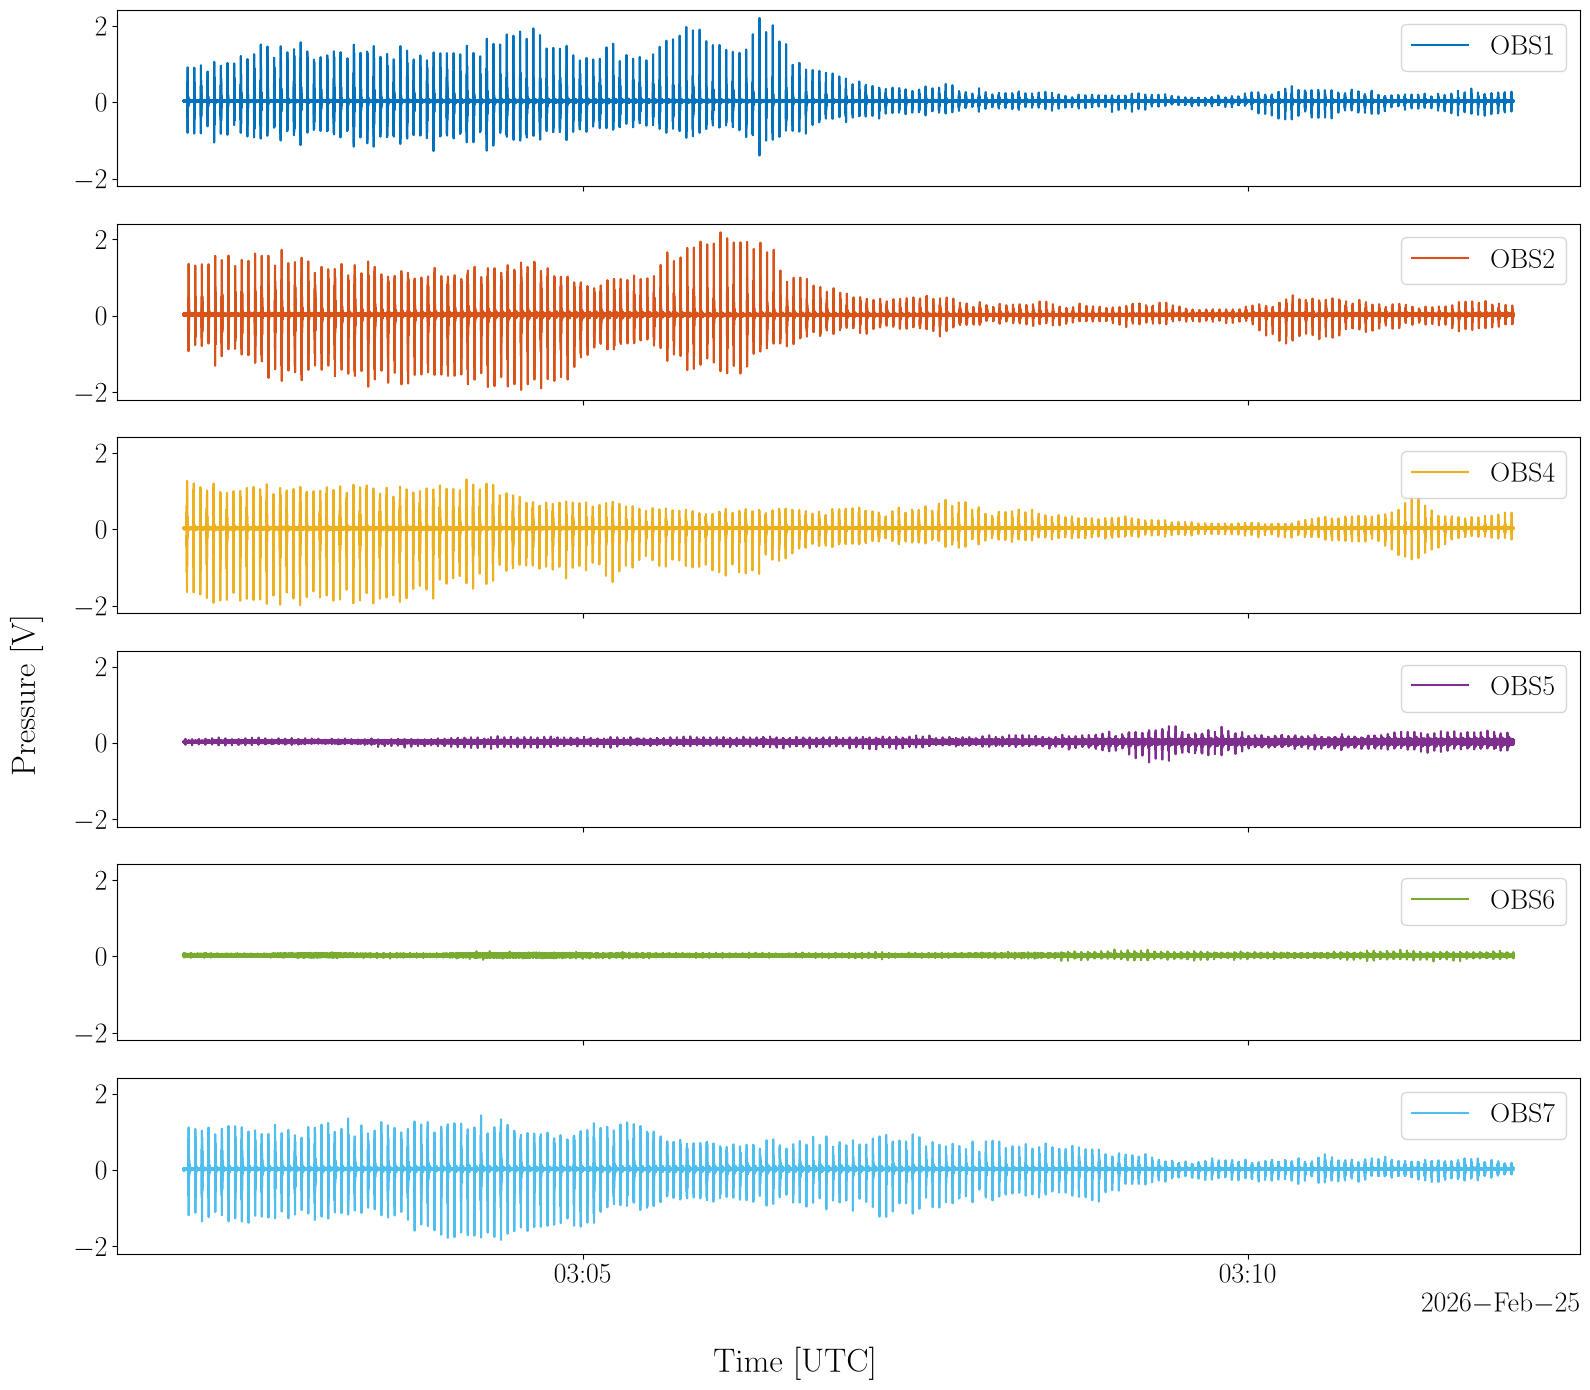

In [22]:
ds_pressure_section_oe2 = extract_and_plot_pressure_section(section_oe2_start, section_oe2_end, ds_pressure, obs_datetimes, single_fig=False)

### Section Ouest Est 3

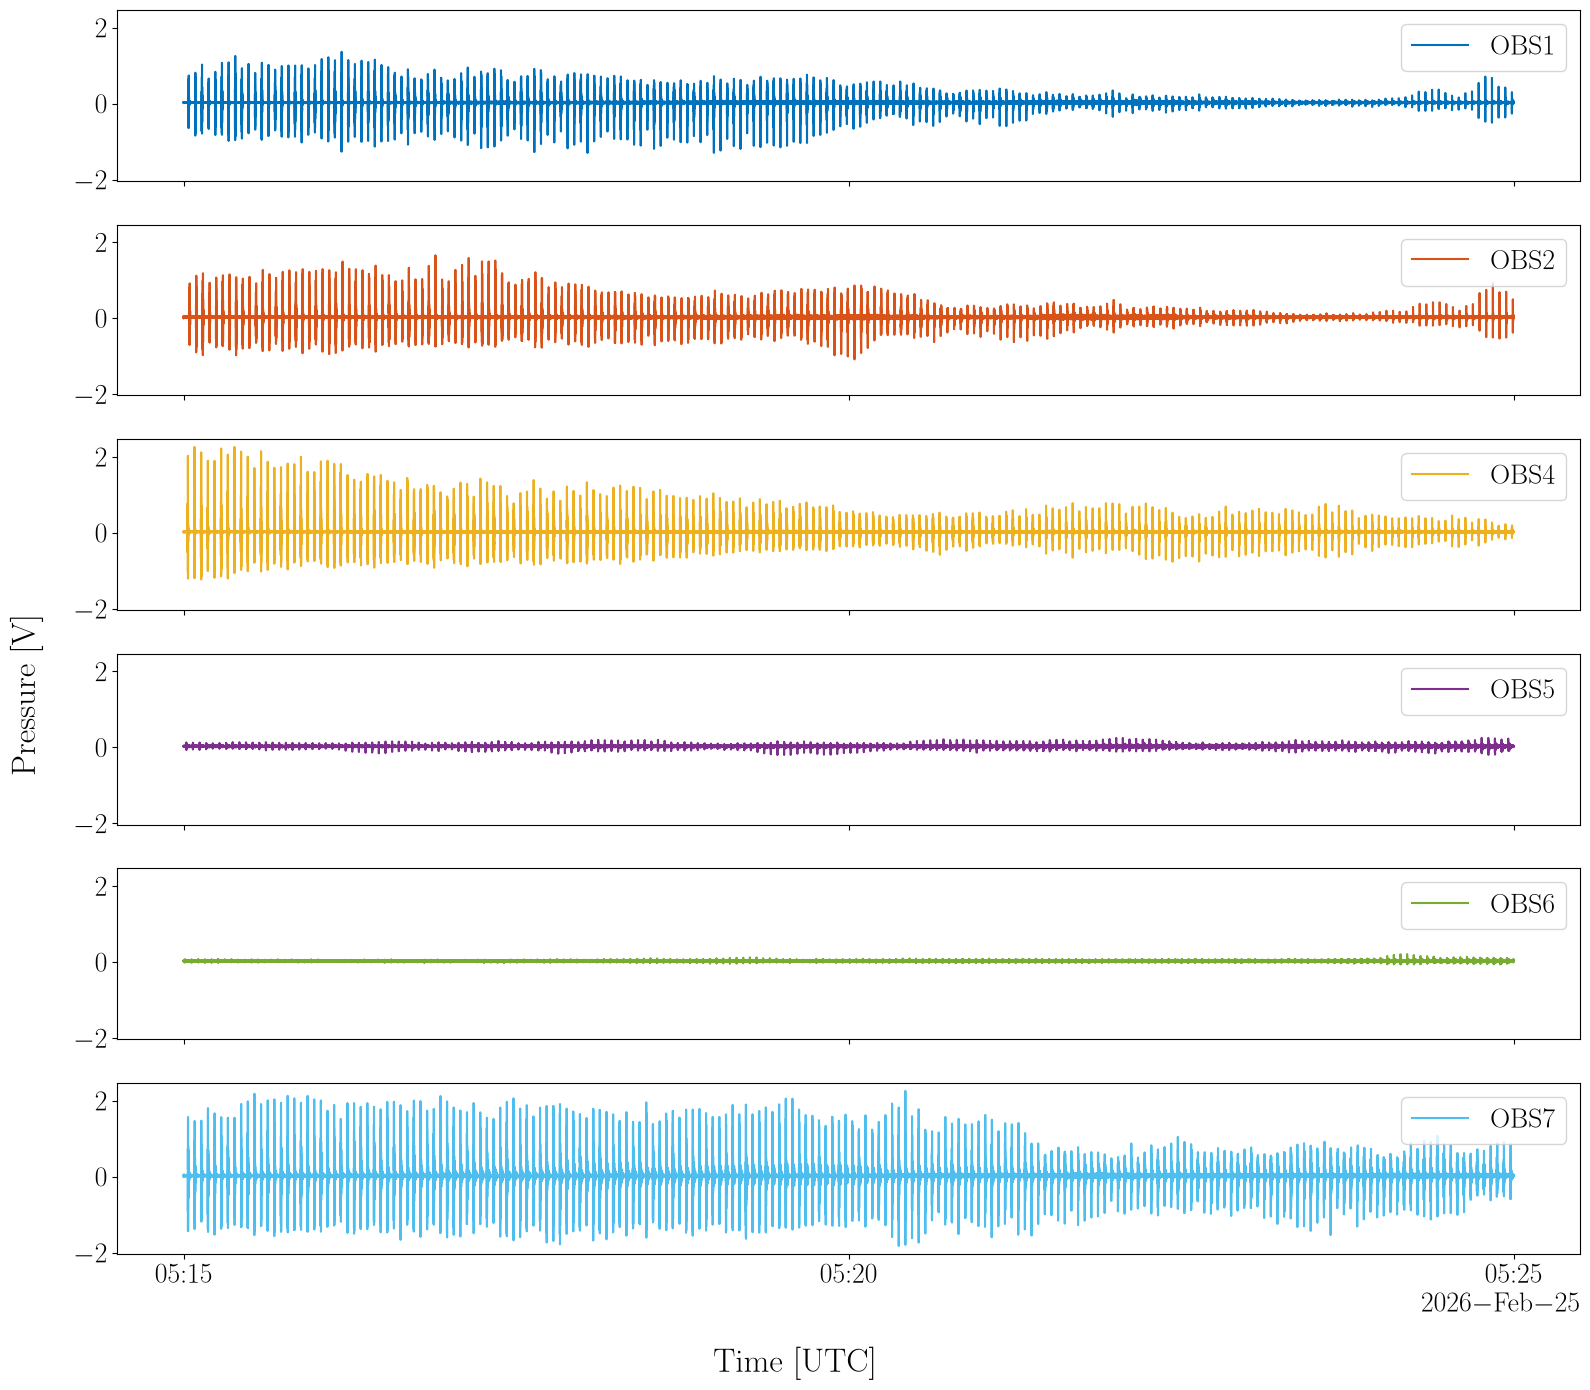

In [23]:
ds_pressure_section_oe3 = extract_and_plot_pressure_section(section_oe3_start, section_oe3_end, ds_pressure, obs_datetimes, single_fig=False)